In [12]:
%load_ext autoreload
%autoreload 2
import numpy as np
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import scipy
from scripts.loglikelihood import logpdf_GAU_ND,loglikelihood
from scripts.utils import getRow, init_dataset, getC,getMu

We now create a function to compute the log-density of a multivariate Gaussian distribution:

$$ \log \mathcal{N} (\mathbf{x}|\boldsymbol{\mu}, \boldsymbol{\Sigma}) = -\frac{M}{2} \log 2\pi - \frac{1}{2} \log |\boldsymbol{\Sigma}| - \frac{1}{2} (\mathbf{x} - \boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu}) $$

> See implementation in [`scripts/loglikelihood.py`](../scripts/loglikelihood.py): functions `logpdf_GAU_ND` (log-pdf evaluation) and `loglikelihood` (total log-likelihood).

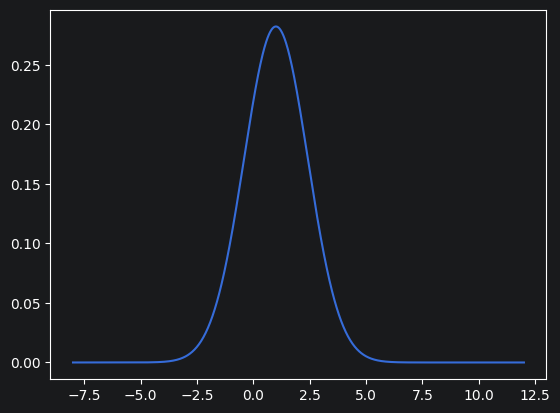

In [3]:
plt.figure()
XPlot = np.linspace(-8, 12, 1000)
m = np.ones((1,1)) * 1.0
C = np.ones((1,1)) * 2.0
plt.plot(XPlot.ravel(), np.exp(logpdf_GAU_ND(getRow(XPlot), m, C)))
plt.show()

In [5]:

XND = np.load('npy/XND.npy')

m_ML = np.array([[-0.07187197], [0.05979594]])
C_ML = np.array([[0.94590166, 0.09313534], [0.09313534, 0.8229693]])
ll = loglikelihood(XND, m_ML, C_ML)
print(ll)


-270.70478023795056


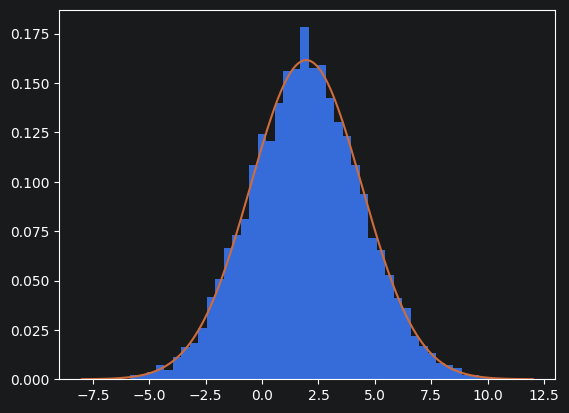

In [6]:

X1D = np.load('npy/X1D.npy')
m_ML = X1D.mean(axis=1, keepdims=True)
C_ML = ((X1D - m_ML) @ (X1D - m_ML).T) / X1D.shape[1]
plt.figure()
plt.hist(X1D.ravel(), bins=50, density=True)
XPlot = np.linspace(-8, 12, 1000)
plt.plot(XPlot.ravel(), np.exp(logpdf_GAU_ND(getRow(XPlot), m_ML, C_ML)))


In [7]:
ll = loglikelihood(X1D, m_ML, C_ML)
print(ll)

-23227.077654602715


Let us now apply what we have built to the Iris Dataset.

In [9]:
D,L,classes,features=init_dataset()

Le classi sono : ['setosa' 'versicolor' 'virginica'] e le features :['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


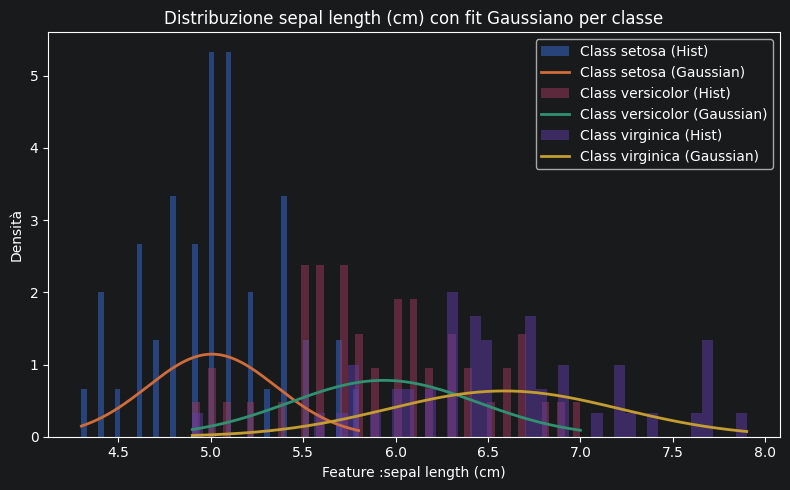

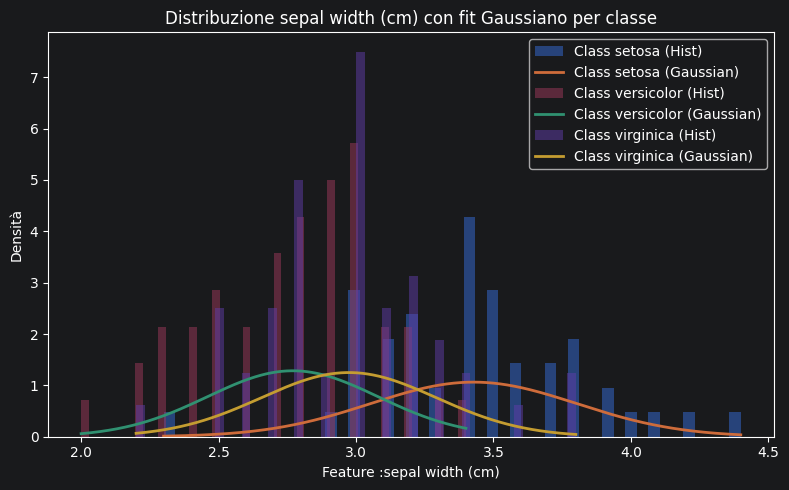

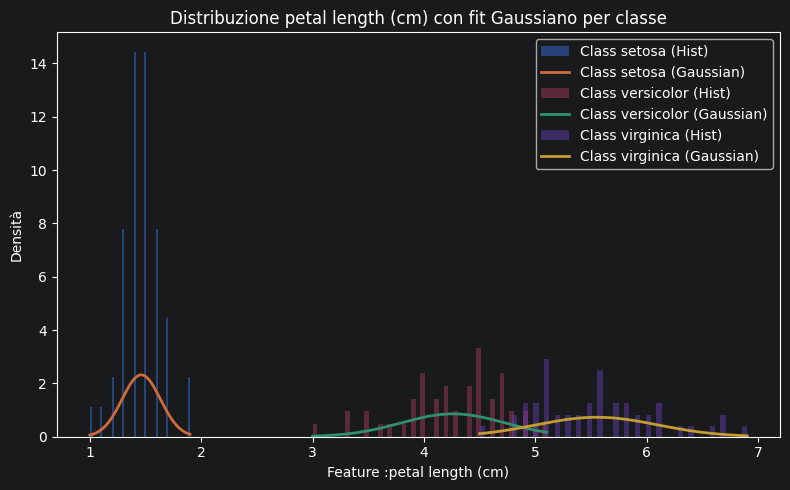

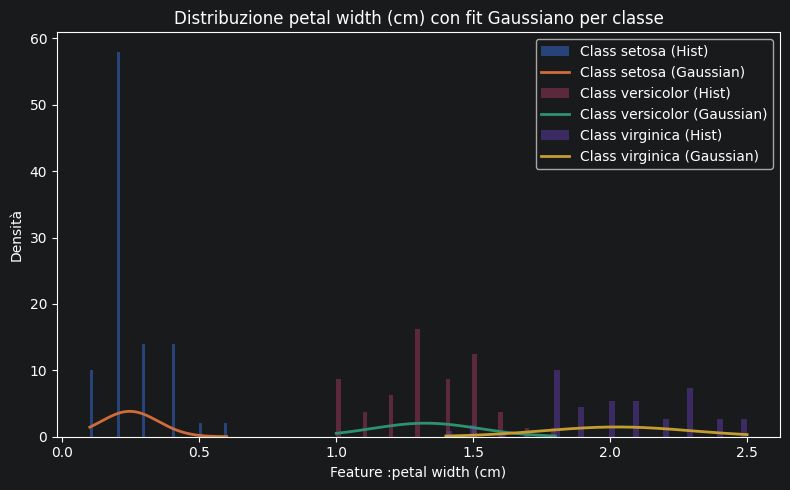

In [11]:
n_features = D.shape[0]
for i in range(n_features):
    plt.figure(figsize=(8, 5))

    for cnt in range(len(classes)):
        mask = L == cnt
        D0 = getRow(D[i, mask])
        mu = getMu(D0)
        C = getC(D0)

        plt.hist(D0.ravel(), bins=50, density=True, alpha=0.5, label=f'Class {classes[cnt]} (Hist)')
        XPlot = np.linspace(D0.min(), D0.max(), 1000)
        pdf_values = np.exp(logpdf_GAU_ND(getRow(XPlot), mu, C))
        plt.plot(XPlot.ravel(), pdf_values.ravel(), linewidth=2, label=f'Class {classes[cnt]} (Gaussian)')

    plt.title(f'Distribuzione {features[i]} con fit Gaussiano per classe')
    plt.xlabel(f'Feature :{features[i]}')
    plt.ylabel('Densità')
    plt.legend()
    plt.tight_layout()
    plt.show()